In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('dataset/babies.csv')
df

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0
...,...,...,...,...,...,...,...,...
1231,1232,113,275.0,1,27.0,60.0,100.0,0.0
1232,1233,128,265.0,0,24.0,67.0,120.0,0.0
1233,1234,130,291.0,0,30.0,65.0,150.0,1.0
1234,1235,125,281.0,1,21.0,65.0,110.0,0.0


In [3]:
df.head()

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   case       1236 non-null   int64  
 1   bwt        1236 non-null   int64  
 2   gestation  1223 non-null   float64
 3   parity     1236 non-null   int64  
 4   age        1234 non-null   float64
 5   height     1214 non-null   float64
 6   weight     1200 non-null   float64
 7   smoke      1226 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 77.4 KB


In [5]:
df.describe()

,case,bwt,gestation,parity,age,height,weight,smoke
count,1236.000000,1236.000000,1223.000000,1236.000000,1234.000000,1214.000000,1200.000000,1226.000000
mean,618.500000,119.576861,279.338512,0.254854,27.255267,64.047776,128.625833,0.394780
std,356.946775,18.236452,16.027693,0.435956,5.781405,2.533409,20.971862,0.489003
min,1.000000,55.000000,148.000000,0.000000,15.000000,53.000000,87.000000,0.000000
25%,309.750000,108.750000,272.000000,0.000000,23.000000,62.000000,114.750000,0.000000
50%,618.500000,120.000000,280.000000,0.000000,26.000000,64.000000,125.000000,0.000000
75%,927.250000,131.000000,288.000000,1.000000,31.000000,66.000000,139.000000,1.000000
max,1236.000000,176.000000,353.000000,1.000000,45.000000,72.000000,250.000000,1.000000


In [6]:
# finding missing value
df.isna().sum()

case          0
bwt           0
gestation    13
parity        0
age           2
height       22
weight       36
smoke        10
dtype: int64

In [7]:

df.dropna(inplace=True)

In [8]:
df.isnull().sum()

case         0
bwt          0
gestation    0
parity       0
age          0
height       0
weight       0
smoke        0
dtype: int64

In [9]:
import matplotlib.pyplot as plt

In [10]:
df.columns

Index(['case', 'bwt', 'gestation', 'parity', 'age', 'height', 'weight',
       'smoke'],
      dtype='object')

In [11]:
df.drop(columns=['case'], inplace=True)

In [12]:
df.columns

Index(['bwt', 'gestation', 'parity', 'age', 'height', 'weight', 'smoke'], dtype='object')

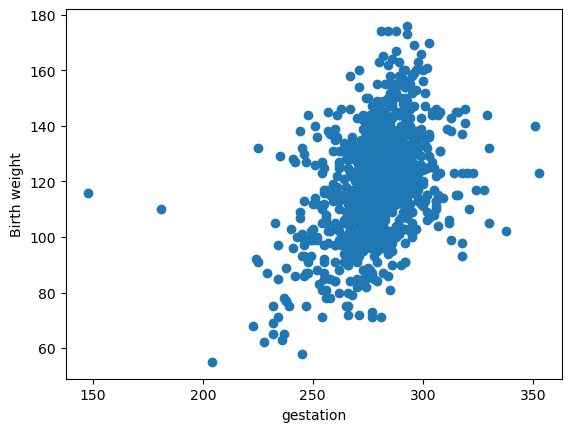

In [13]:
plt.scatter(df['gestation'],df['bwt'])
plt.xlabel('gestation')
plt.ylabel('Birth weight')
plt.show()

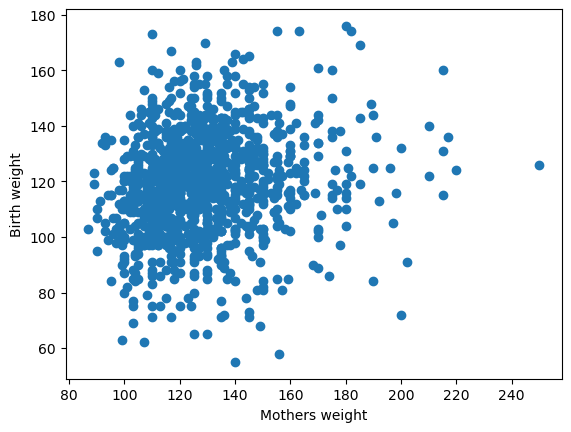

In [14]:
plt.scatter(df['weight'],df['bwt'])
plt.xlabel('Mothers weight')
plt.ylabel('Birth weight')
plt.show()

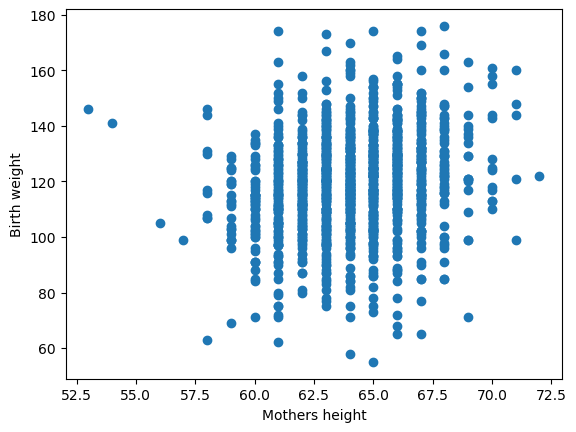

In [15]:
plt.scatter(df['height'],df['bwt'])
plt.xlabel('Mothers height')
plt.ylabel('Birth weight')
plt.show()

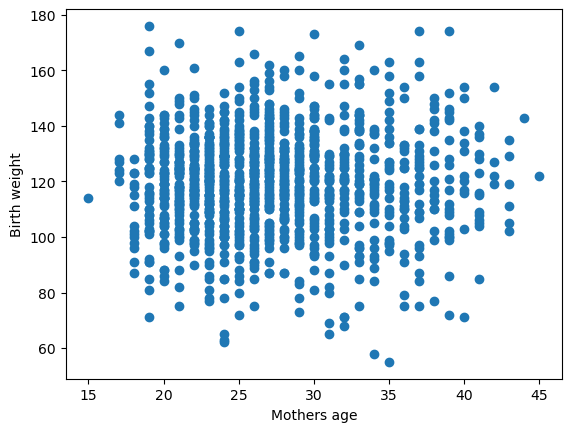

In [16]:
plt.scatter(df['age'],df['bwt'])
plt.xlabel('Mothers age')
plt.ylabel('Birth weight')
plt.show()

In [17]:
df['smoke'].unique()

array([0., 1.])

In [18]:
df['smoke'].value_counts(normalize=True)*100

smoke
0.0    60.902896
1.0    39.097104
Name: proportion, dtype: float64

In [19]:
df['parity'].unique()

array([0, 1])

In [20]:
df['parity'].value_counts()

parity
0    866
1    308
Name: count, dtype: int64

In [21]:
# correlation matrix

df.corr()

,bwt,gestation,parity,age,height,weight,smoke
bwt,1.000000,0.407543,-0.043908,0.026983,0.203704,0.155923,-0.246800
gestation,0.407543,1.000000,0.080916,-0.053425,0.070470,0.023655,-0.060267
parity,-0.043908,0.080916,1.000000,-0.351041,0.043543,-0.096362,-0.009599
age,0.026983,-0.053425,-0.351041,1.000000,-0.006453,0.147322,-0.067772
height,0.203704,0.070470,0.043543,-0.006453,1.000000,0.435287,0.017507
weight,0.155923,0.023655,-0.096362,0.147322,0.435287,1.000000,-0.060281
smoke,-0.246800,-0.060267,-0.009599,-0.067772,0.017507,-0.060281,1.000000


In [22]:
# Splitting dataset into x and y
y=df['bwt']
x=df.iloc[:, 1:]
x.head()

,gestation,parity,age,height,weight,smoke
0,284.0,0,27.0,62.0,100.0,0.0
1,282.0,0,33.0,64.0,135.0,0.0
2,279.0,0,28.0,64.0,115.0,1.0
4,282.0,0,23.0,67.0,125.0,1.0
5,286.0,0,25.0,62.0,93.0,0.0


In [23]:
# train test split
from sklearn.model_selection import train_test_split 
x_train, x_test,y_train, y_test=train_test_split(x, y, test_size=0.20)

In [24]:
x_train.shape,x_test.shape

((939, 6), (235, 6))

In [25]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
lr=LinearRegression()
lasso=Lasso()
ridge=Ridge()

In [26]:
lr.fit(x_train, y_train)
lasso.fit(x_train,y_train)
ridge.fit(x_train, y_train)

Ridge()

In [27]:
lr_pred = lr.predict(x_test)
las_pred = lasso.predict(x_test)
rid_pred = ridge.predict(x_test)

In [28]:
# Model evaluation

from sklearn.metrics import r2_score, mean_squared_error

In [29]:
lr_rscore=r2_score(y_test, lr_pred)
las_rscore =r2_score(y_test, las_pred)
rid_rscore=r2_score(y_test, rid_pred)

In [30]:
lr_mse=mean_squared_error(y_test, lr_pred)
las_mse =mean_squared_error(y_test, las_pred)
rid_mse=mean_squared_error(y_test, rid_pred)

In [31]:
print('\n Performance of Linear Regression Model : ')
print('R2 score : ', lr_rscore)
print('MSE : ',lr_mse)

print('\n Performance of Lasso Regression Model : ')
print('R2 score : ', las_rscore)
print('MSE : ',las_mse)

print('\n Performance of Ridge Regression Model : ')
print('R2 score : ', rid_rscore)
print('MSE : ', rid_mse)


 Performance of Linear Regression Model : 
R2 score :  0.19511778001827706
MSE :  230.83590660950662

 Performance of Lasso Regression Model : 
R2 score :  0.160396672178156
MSE :  240.79373423668764

 Performance of Ridge Regression Model : 
R2 score :  0.19506716762589593
MSE :  230.85042197236461


In [32]:
## Selected model is linear regression
 # pickinf the model
import pickle

In [34]:
with open("model/model.pkl", 'wb') as f:  # f - file path
    pickle.dump(lr, f)

In [35]:
 ## Load the pickle file
with open('model/model.pkl','rb') as obj:
    mymodel = pickle.load(obj)

In [36]:
x_train.head()

,gestation,parity,age,height,weight,smoke
1211,265.0,0,21.0,65.0,103.0,1.0
36,279.0,0,24.0,63.0,115.0,0.0
549,292.0,1,25.0,65.0,125.0,0.0
1031,294.0,1,21.0,65.0,132.0,0.0
750,273.0,0,22.0,66.0,130.0,1.0


In [37]:
test_data={
    "gestation":[284.0],
    "parity":[0],
    "age":[29.0],	
    "height":[68.0],	
    "weight":[140.0],	
    "smoke":[0.0]
}

In [38]:
import pandas as pd
test_df=pd.DataFrame(test_data)
test_df

,gestation,parity,age,height,weight,smoke
0,284.0,0,29.0,68.0,140.0,0.0


In [39]:
mymodel.predict(test_df)

array([130.1371835])